Data generated by Todd is missing alpha's and delta's for intermediate potentials - probably to keep data clean and accurate and not get bogged down by experimental error <br>
I am going to calculate my own kinetic parameters and cross verify with Todd's data by plotting <br>
Experimental parameters: <br>
KOH/HClO4 concs: 0.1, 0.25, 0.5, 1 (M) <br>
CO Pressure: 0.1, 1, 10, 100 <br>
16 different condiitons for each acidic/basic CO oxidation: 4 different setups <br>
Assume that pH reaction order data will be less accurate than CO reaction order or transfer coefficient data - different setups for different pHs <br>
Potential ranges: 0.5 - 1 (vs RHE) <br>
Catalysts: Pt100, Pt66Ru33, Pt50Ru50 <br>
<br>
Units: <br>
Potential: V vs RHE <br>
Current: mA/cm2 <br>
<br>
This time data has replicates (4 replicates for each condition) <br>
Data was interpolated (Pchipinterpolation) to put all data sets on the same grid. <br>
Savgol is currently not working. <br>
Calculate mean and SD for each data point (current first). <br> 
Calculate mean and SD for KOs. Calculate individual KOs first and then average. <br>
Save final data and import in different workspace. <br>

# Initialization

In [33]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

import sys
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import _utils

In [34]:
# Experimental conditions (Pt100 KOH) and constants

C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
trials = [1, 2, 3, 4]
conditions = list(itertools.product(C_KOH_list, P_CO_list))
conditions_trials = list(itertools.product(C_KOH_list, P_CO_list, trials))

R, T, F = 8.3145, 298.15, 96485
n = 2 # number of electrons transferred in the reaction

In [35]:
# Load current density data + classification

excel_file = 'Summary_Pt_replicates.xlsx'
experiments = {}
for C_KOH in C_KOH_list: 
    for trial in trials: 
        sheet_name = f'{int(C_KOH*1000)} mM KOH - Trial {trial}'
        df = pd.read_excel(excel_file, sheet_name=sheet_name, header=None)
        for i, P_CO in enumerate(P_CO_list): 
            col_idx = i * 2
            subset = df.iloc[2:, col_idx : col_idx+2].copy()
            subset.columns = ['E', 'j']
            # Force numeric, coerce bad values/text to NaN, then drop
            subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
            subset['j'] = pd.to_numeric(subset['j'], errors='coerce')
            subset = subset.dropna()
            experiments[(C_KOH, P_CO, trial)] = subset

# Smoothing and Interpolating

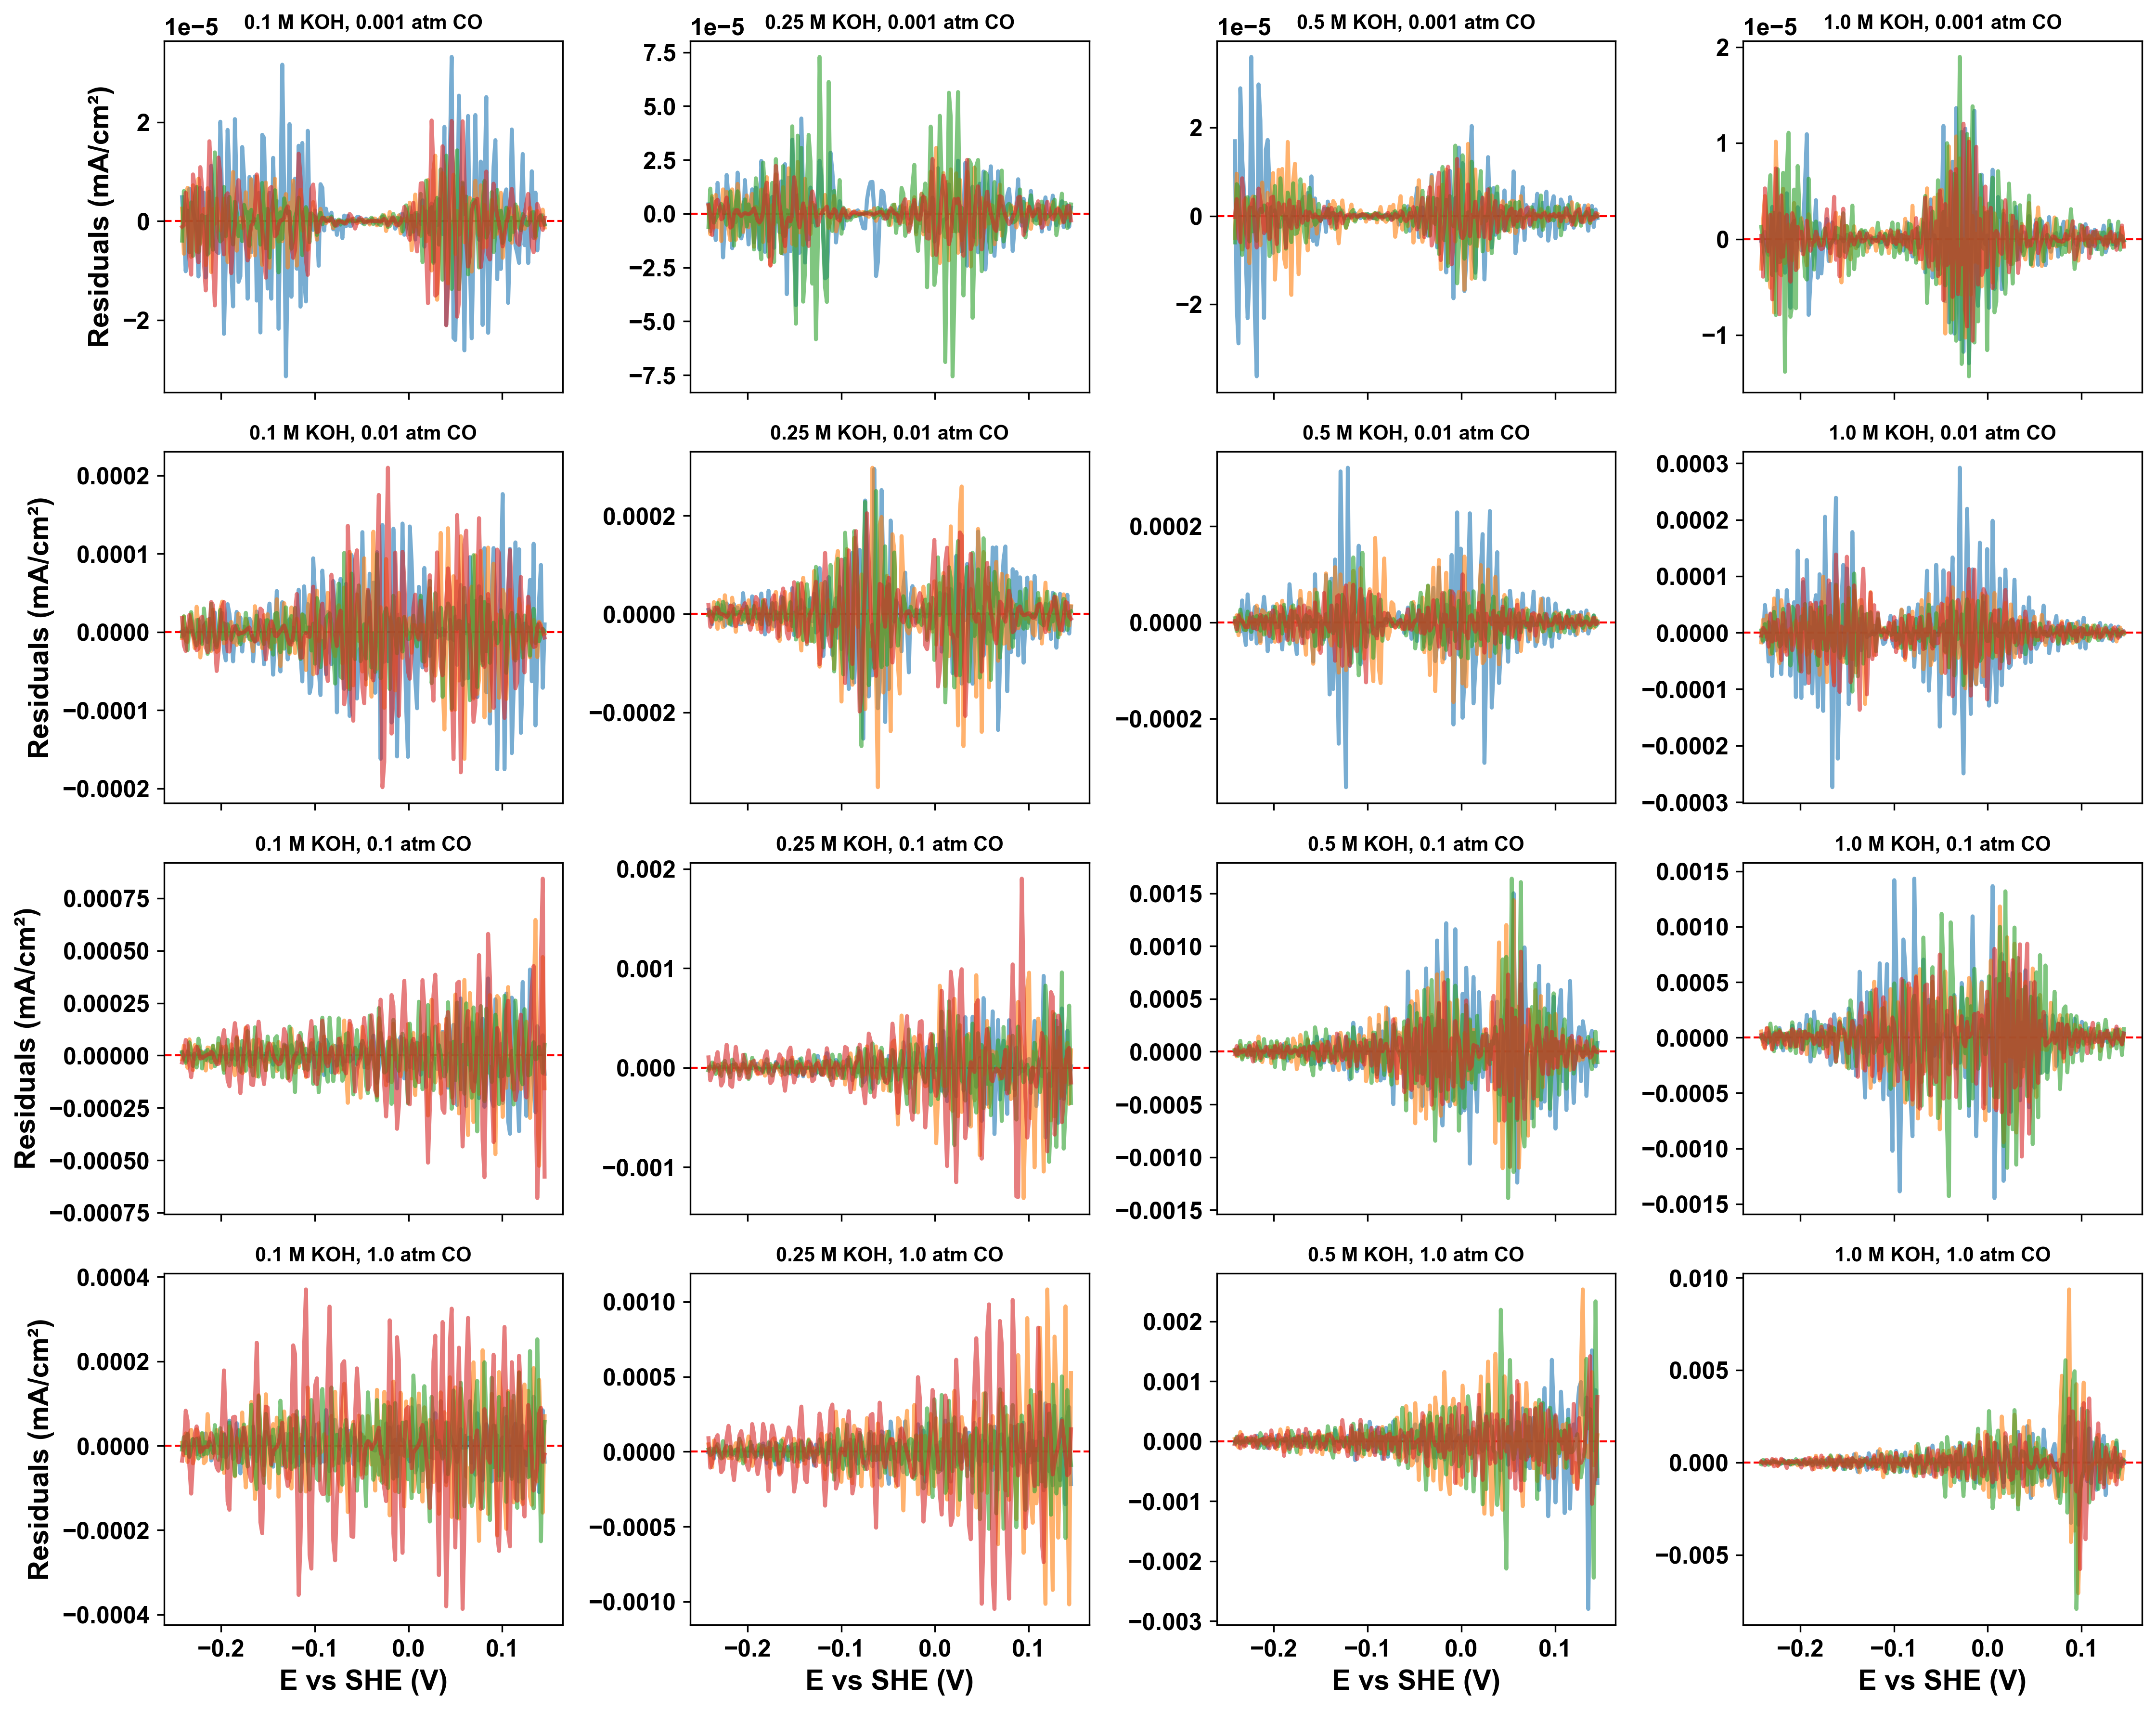

In [36]:
# Convert potential to SHE scale and interpolate to common E points
for (C_KOH, P_CO, trial) in conditions_trials:
    E_ref = 0 - 0.0592*(14 + np.log10(C_KOH))
    experiments[(C_KOH, P_CO, trial)]['E_SHE'] = experiments[(C_KOH, P_CO, trial)]['E'] + E_ref

min_E = max(experiments[c]['E_SHE'].min() for c in experiments)
max_E = min(experiments[c]['E_SHE'].max() for c in experiments)
E_interp_SHE = np.linspace(min_E, max_E, 200)
fig, axes = plt.subplots(nrows=len(P_CO_list), ncols=len(C_KOH_list), figsize=(15, 12), sharex=True, sharey=False)

# Store interpolated data separately
experiments_interp = {}
for i, P_CO in enumerate(P_CO_list):
    for k, C_KOH in enumerate(C_KOH_list):
        ax = axes[i, k]
        ax.axhline(0, color='red', linestyle='--', linewidth=1) 
        ax.set_title(f'{C_KOH} M KOH, {P_CO} atm CO', fontsize=10)
        for trial in trials:
            condition = (C_KOH, P_CO, trial)
            E = experiments[condition]['E_SHE']
            j = experiments[condition]['j']
        
            f_interp = PchipInterpolator(E, j)
            j_interp = f_interp(E_interp_SHE)
            j_smooth = savgol_filter(j_interp, window_length=11, polyorder=3) 

            experiments_interp[condition] = {}
            experiments_interp[condition]['j_rough'] = j_interp
            experiments_interp[condition]['j'] = j_interp
            experiments_interp[condition]['E'] = E_interp_SHE # E is vs SHE
            experiments_interp[condition]['log_rate'] = np.log(j_interp / (1000 * n * F))

            residuals = j_interp - j_smooth 
            ax.plot(E_interp_SHE, residuals, alpha=0.6)
        
        if k == 0:
            ax.set_ylabel('Residuals (mA/cm²)')
        if i == len(P_CO_list) - 1:
            ax.set_xlabel('E vs SHE (V)')

plt.tight_layout()
plt.show()

# Currents

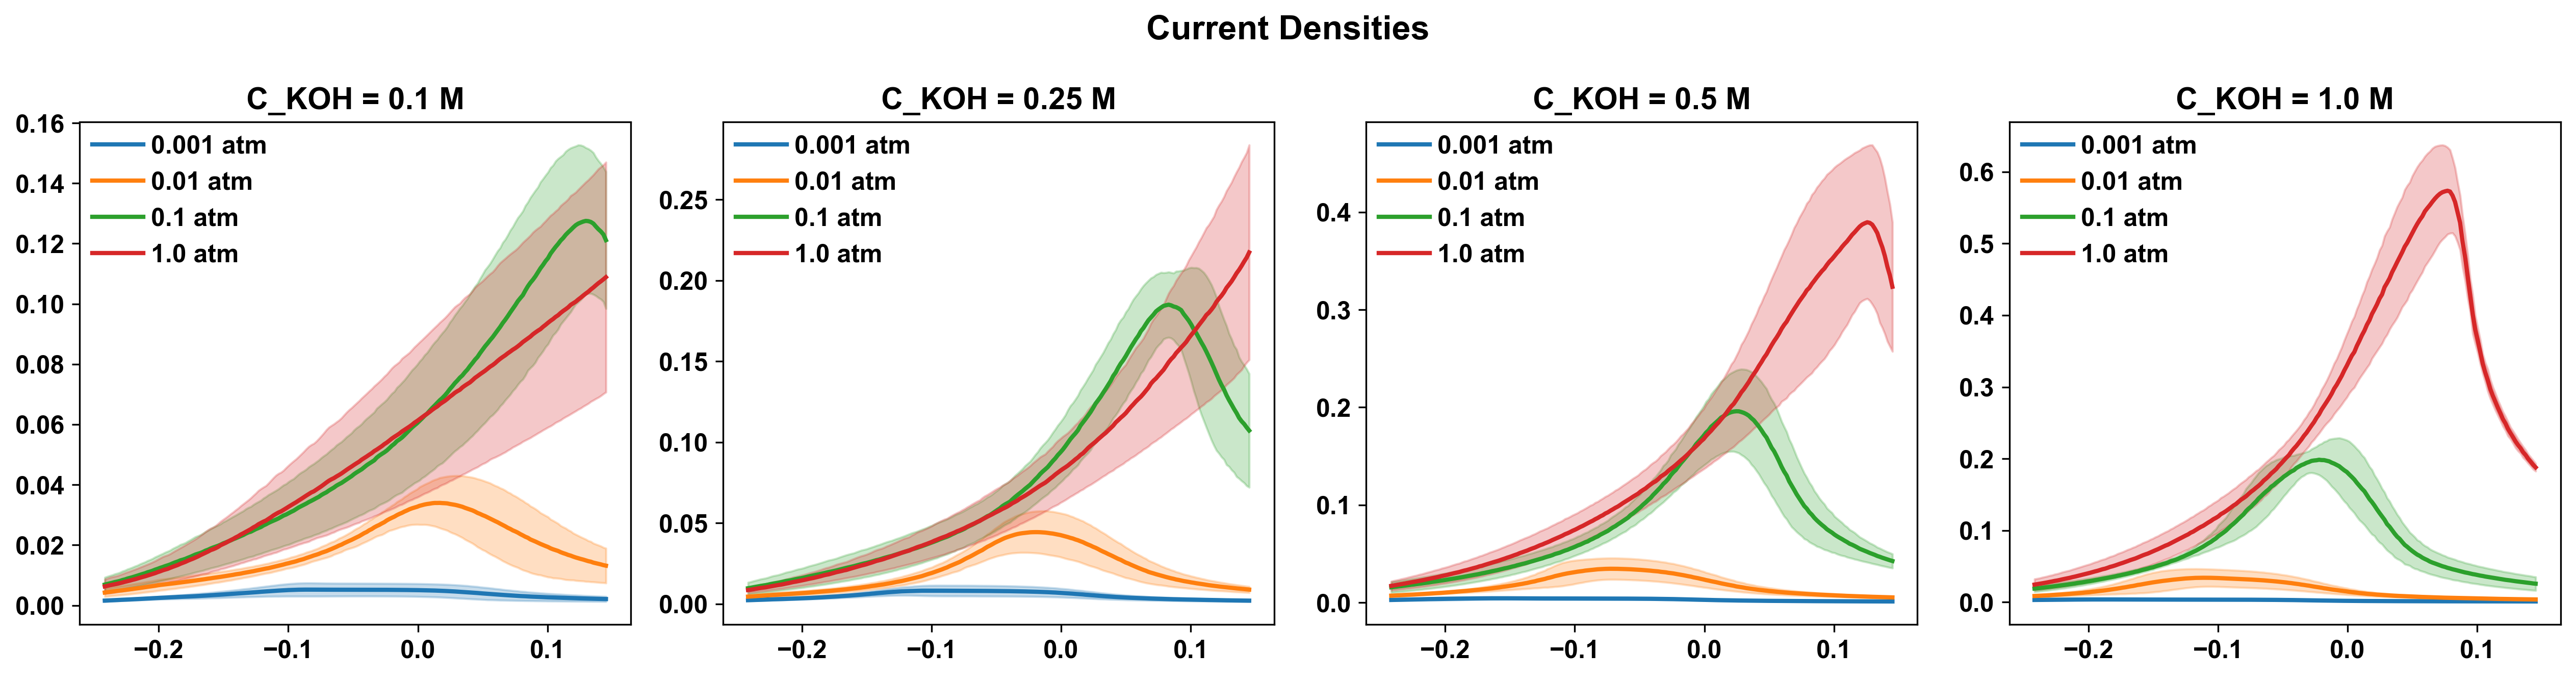

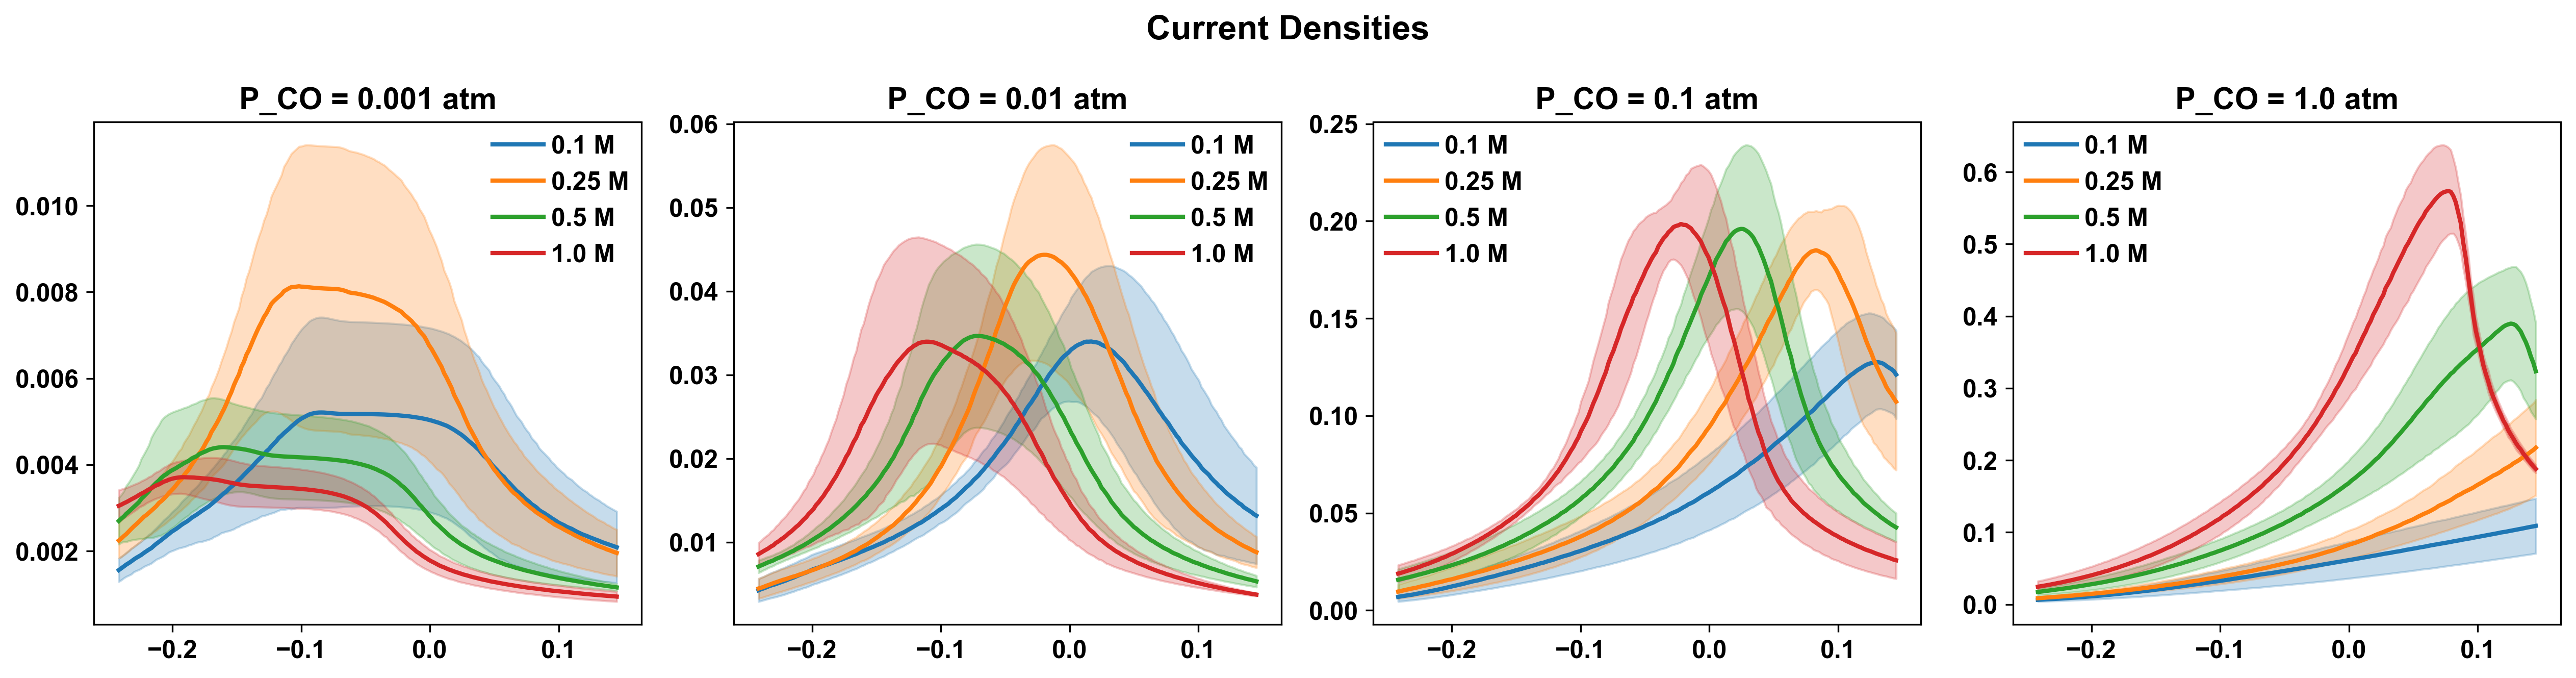

In [37]:
# Calculating current mean + SD 
experiments_mean = {}
for (C_KOH, P_CO) in conditions:
    
    j_trials = []; rate_trials = []
    for trial in trials:
        j_trials.append(experiments_interp[(C_KOH, P_CO, trial)]['j'])
        rate_trials.append(experiments_interp[(C_KOH, P_CO, trial)]['log_rate'])
    j_array = np.array(j_trials); rate_array = np.array(rate_trials)
    
    experiments_mean[(C_KOH, P_CO)] = {}
    experiments_mean[(C_KOH, P_CO)]['E'] = E_interp_SHE 
    experiments_mean[(C_KOH, P_CO)]['j'] = np.mean(j_array, axis=0)
    experiments_mean[(C_KOH, P_CO)]['j_SD'] = np.std(j_array, axis=0, ddof=1)
    experiments_mean[(C_KOH, P_CO)]['log_rate'] = np.mean(rate_array, axis=0)
    experiments_mean[(C_KOH, P_CO)]['log_rate_SD'] = np.std(rate_array, axis=0, ddof=1)

# Plotting current densities
fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Current Densities', fontsize=16, fontweight='bold')
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(1, 4, i + 1)
    plt.title(f'C_KOH = {C_KOH} M')
    for P_CO in P_CO_list:
        E = experiments_mean[(C_KOH, P_CO)]['E']
        j = experiments_mean[(C_KOH, P_CO)]['j']
        j_SD = experiments_mean[(C_KOH, P_CO)]['j_SD']
        line = ax.plot(E, j, label=f'{P_CO} atm', linewidth=2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.25)
    plt.legend()
plt.tight_layout()

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Current Densities', fontsize=16, fontweight='bold')
for i, P_CO in enumerate(P_CO_list):
    ax = plt.subplot(1, 4, i + 1) 
    plt.title(f'P_CO = {P_CO} atm')
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['E']
        j = experiments_mean[condition]['j']
        j_SD = experiments_mean[condition]['j_SD'] 
        line = ax.plot(E, j, label=f'{C_KOH} M', linewidth=2)
        ax.fill_between(E, j - j_SD, j + j_SD, color=line[0].get_color(), alpha=0.25)
    plt.legend()
plt.tight_layout()

In [38]:
# Load Todd's alpha data + classification

alpha_todd_raw = pd.read_excel('Summary_Pt_replicates.xlsx', sheet_name='TC')
alpha_todd = {}
for i, (C_KOH, P_CO) in enumerate(conditions):
    col_idx = i * 3
    subset = alpha_todd_raw.iloc[3:, col_idx : col_idx+3].copy()
    subset.columns = ['E', 'alpha', 'alpha_SD'] # in RHE
    subset = subset.dropna()
    alpha_todd[(C_KOH, P_CO)] = subset
    
    E_ref = 0 - 0.0592*(14 + np.log10(C_KOH))
    alpha_todd[(C_KOH, P_CO)]['E'] = alpha_todd[(C_KOH, P_CO)]['E'] + E_ref

In [39]:
# Calculate alpha from current data

for condition_trial in conditions_trials:
    E = experiments_interp[condition_trial]['E']
    j = experiments_interp[condition_trial]['j']
    lnj = np.log(j)

    alpha = (R*T/F)*np.gradient(lnj, E)    
    experiments_interp[condition_trial]['alpha'] = alpha

for condition in conditions:
    C_KOH, P_CO = condition
    alpha_trials = []
    for trial in trials:
        condition_trial = (C_KOH, P_CO, trial)
        alpha_trials.append(experiments_interp[condition_trial]['alpha'])
    alpha_array = np.array(alpha_trials)
    experiments_mean[condition]['alpha'] = np.mean(alpha_array, axis=0)
    experiments_mean[condition]['alpha_SD'] = np.std(alpha_array, axis=0, ddof=1)

# Transfer Coefficients

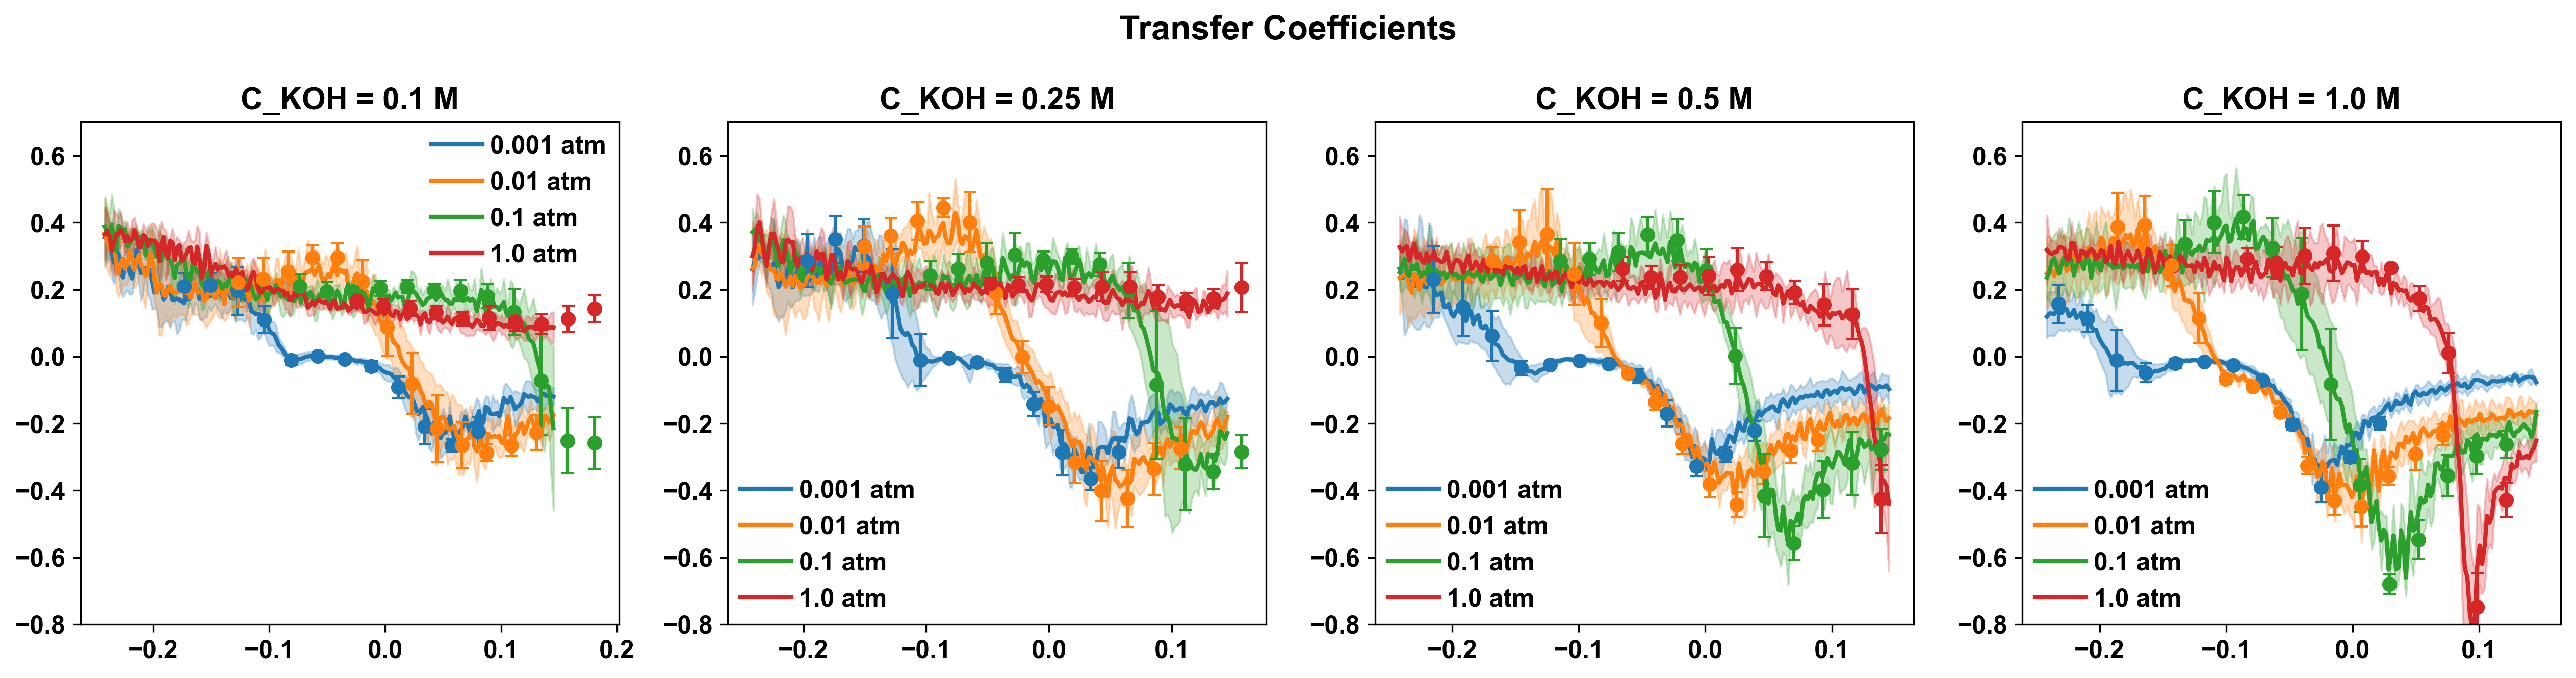

In [40]:
# Plotting alphas 

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Transfer Coefficients', fontsize=16, fontweight='bold')
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {C_KOH} M') 
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        E = experiments_mean[condition]['E']
        alpha = experiments_mean[condition]['alpha']
        alpha_SD = experiments_mean[condition]['alpha_SD']
        line = ax.plot(E, alpha, label=f'{P_CO} atm', linewidth=2)
        ax.fill_between(E, alpha - alpha_SD, alpha + alpha_SD, color=line[0].get_color(), alpha=0.25)
        
        E_todd = alpha_todd[condition]['E']
        alpha_todd_val = alpha_todd[condition]['alpha']
        alpha_todd_SD = alpha_todd[condition]['alpha_SD']
        ax.errorbar(E_todd, alpha_todd_val, yerr=alpha_todd_SD, fmt='o', markersize=6, color=line[0].get_color(), capsize=3, elinewidth=1.5)
        
    ax.set_ylim(-0.8, 0.7)
    ax.legend()
plt.tight_layout()

In [41]:
# Load Todd's delta_OH data + classification

delta_OH_todd_raw = pd.read_excel('Summary_Pt_replicates.xlsx', sheet_name='OH- Order')
delta_OH_todd = {}
for i, P_CO in enumerate(P_CO_list):
    col_idx = i * 3
    subset = delta_OH_todd_raw.iloc[3:, col_idx : col_idx+3].copy()
    subset.columns = ['E', 'delta_OH', 'delta_OH_SD'] # in SHE
    subset = subset.dropna()
    delta_OH_todd[(P_CO)] = subset

In [42]:
# Calculate delta_OH from current data

for P_CO in P_CO_list:
    for trial in trials:
        j_interp_matrix = []
        for C_KOH in C_KOH_list:
            j_interp_matrix.append(experiments_interp[(C_KOH, P_CO, trial)]['j'])
        delta_OH = np.polyfit(np.log(C_KOH_list).transpose(), np.log(j_interp_matrix), deg=1)[0]
        for C_KOH in C_KOH_list: experiments_interp[(C_KOH, P_CO, trial)]['delta_OH'] = delta_OH    

for condition in conditions: 
    C_KOH, P_CO = condition
    delta_OH_trials = [experiments_interp[(C_KOH, P_CO, trial)]['delta_OH'] for trial in trials]
    delta_OH_array = np.array(delta_OH_trials)
    experiments_mean[condition]['delta_OH'] = np.mean(delta_OH_array, axis=0)
    experiments_mean[condition]['delta_OH_SD'] = np.std(delta_OH_array, axis=0, ddof=1)

# OH Reaction Order

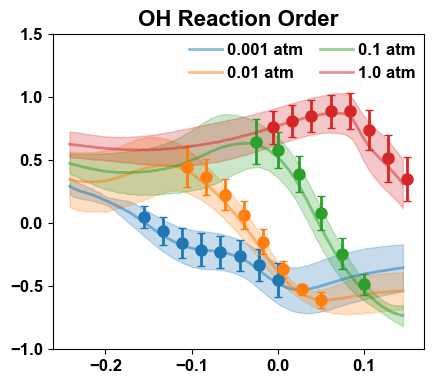

In [43]:
# Plotting delta_OH

fig = plt.figure(figsize=(4.5, 4), dpi=100)
plt.title('OH Reaction Order', fontsize=16, fontweight='bold')
for i, P_CO in enumerate(P_CO_list):
    delta_OH = experiments_mean[(C_KOH_list[1], P_CO)]['delta_OH'] # Arbitrary C_KOH
    delta_OH_SD = experiments_mean[(C_KOH_list[1], P_CO)]['delta_OH_SD'] # Arbitrary C_KOH
    E_SHE = experiments_mean[(C_KOH_list[1], P_CO)]['E'] # Arbitrary C_KOH
    line, = plt.plot(E_SHE, delta_OH, label=f'{P_CO} atm', alpha=0.5) 
    plt.fill_between(E_SHE, delta_OH - delta_OH_SD, delta_OH + delta_OH_SD, color=line.get_color(), alpha=0.25)
    E_todd = delta_OH_todd[(P_CO)]['E']
    delta_OH_todd_val = delta_OH_todd[(P_CO)]['delta_OH']
    delta_OH_todd_SD = delta_OH_todd[(P_CO)]['delta_OH_SD']
    plt.errorbar(E_todd, delta_OH_todd_val, yerr=delta_OH_todd[(P_CO)]['delta_OH_SD'], fmt='o', markersize=8, color=line.get_color())
plt.legend(ncols=2)
plt.ylim(-1, 1.5)
plt.tight_layout()

In [44]:
# Load Todd's delta_CO data + classification

delta_CO_todd_raw = pd.read_excel('Summary_Pt_replicates.xlsx', sheet_name='CO order')
delta_CO_todd = {}
conditions_delta_CO = list(itertools.product(C_KOH_list, P_CO_list[0:-1]))
for i, (C_KOH, P_CO) in enumerate(conditions_delta_CO):
    col_idx = i * 3
    subset = delta_CO_todd_raw.iloc[3:, col_idx : col_idx+3].copy()
    subset.columns = ['E', 'delta_CO', 'delta_CO_SD'] # in RHE
    subset = subset.dropna()
    delta_CO_todd[(C_KOH, P_CO)] = subset

    E_ref = 0 - 0.0592*(14 + np.log10(C_KOH))
    delta_CO_todd[(C_KOH, P_CO)]['E'] = delta_CO_todd[(C_KOH, P_CO)]['E'] + E_ref

In [45]:
# Calculate delta_CO from current data

for (C_KOH, P_CO) in conditions_delta_CO:
    idx = int(np.where(P_CO_list == P_CO)[0][0])
    for trial in trials: 
        E = experiments_interp[(C_KOH, P_CO, trial)]['E']
        j_1 = experiments_interp[(C_KOH, P_CO, trial)]['j']
        j_2 = experiments_interp[(C_KOH, P_CO_list[idx + 1], trial)]['j']
        delta_CO = (np.log(j_2) - np.log(j_1)) / (np.log(P_CO_list[idx + 1]) - np.log(P_CO))
        experiments_interp[(C_KOH, P_CO, trial)]['delta_CO'] = delta_CO

for condition in conditions_delta_CO:
    C_KOH, P_CO = condition
    delta_CO_trials = [experiments_interp[(C_KOH, P_CO, trial)]['delta_CO'] for trial in trials]
    delta_CO_array = np.array(delta_CO_trials)
    experiments_mean[condition]['delta_CO'] = np.mean(delta_CO_array, axis=0)
    experiments_mean[condition]['delta_CO_SD'] = np.std(delta_CO_array, axis=0, ddof=1)

# CO Reaction Order

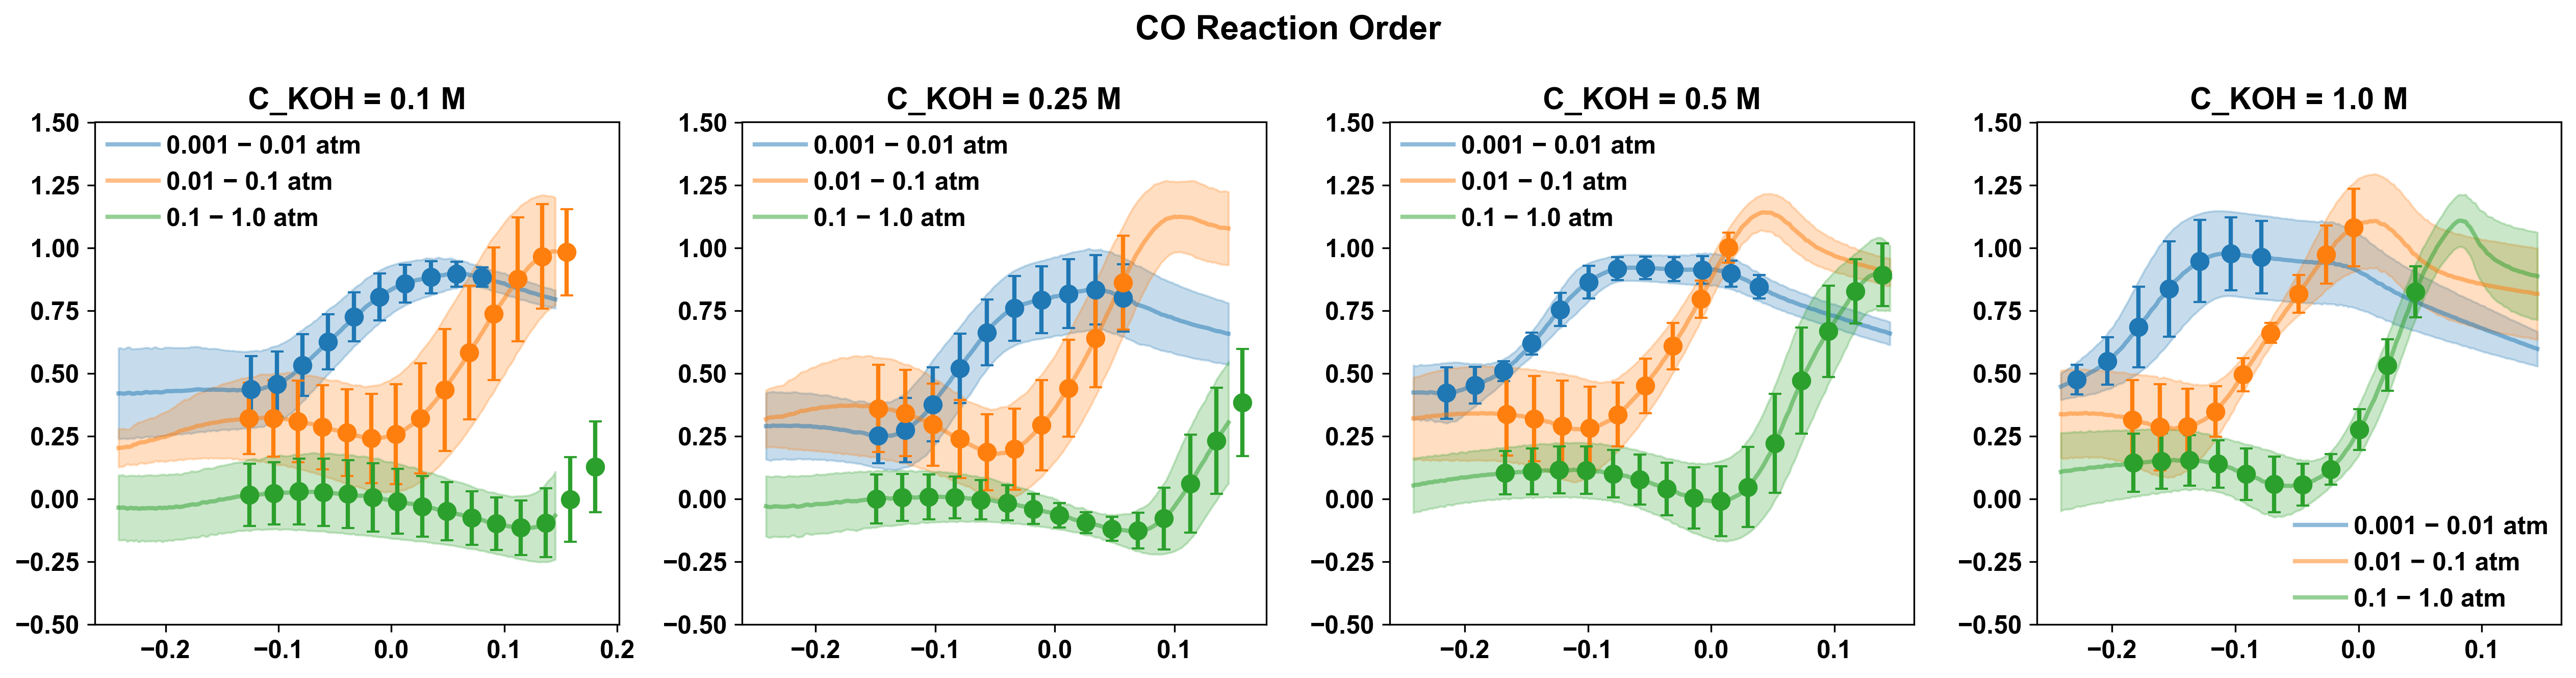

In [46]:
# Plotting delta_CO

fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('CO Reaction Order', fontsize=16, fontweight='bold')
for i, target_KOH in enumerate(C_KOH_list):
    plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {target_KOH} M')
    for (C_KOH, P_CO) in conditions_delta_CO:
        if C_KOH == target_KOH:
            E = experiments_mean[(C_KOH, P_CO)]['E']
            delta_CO = experiments_mean[(C_KOH, P_CO)]['delta_CO']
            delta_CO_SD = experiments_mean[(C_KOH, P_CO)]['delta_CO_SD']
            idx = int(np.where(P_CO_list == P_CO)[0][0])
            P_CO_2 = P_CO_list[idx + 1]
            line, = plt.plot(E, delta_CO, label=f'{P_CO} - {P_CO_2} atm', alpha=0.5)
            plt.fill_between(E, delta_CO - delta_CO_SD, delta_CO + delta_CO_SD, color=line.get_color(), alpha=0.25)
            
            E_todd = delta_CO_todd[(C_KOH, P_CO)]['E']
            delta_CO_todd_val = delta_CO_todd[(C_KOH, P_CO)]['delta_CO']
            delta_CO_todd_SD = delta_CO_todd[(C_KOH, P_CO)]['delta_CO_SD']
            plt.errorbar(E_todd, delta_CO_todd_val, yerr=delta_CO_todd_SD, fmt='o', markersize=8, color=line.get_color(), capsize=3)

    plt.legend()
    plt.ylim(-0.5, 1.5)
plt.tight_layout()

In [47]:
import pickle

with open('Pt100_KOH_replicates.pkl', 'wb') as f:
    pickle.dump(experiments_mean, f)